# Orbyts Session 8: Generating a black hole image

This notebook contains all the necessary code for generating a black hole image.
To generate your own, just use the code here and tweak the parameters! Run the 
next two cells first to load the orbyts-black-hole-shadows package.

In [ ]:
#pip install orbyts_black_hole_shadows

In [14]:
# We need to import three classes from the package: Metric, Box, and Source
from orbyts_black_hole_shadows.utils import Metric
from orbyts_black_hole_shadows.sources import Source, Box
import numpy as np

### Outline

To generate an image we need to follow 4 steps:

1. Specifying a metric, i.e. defining the type of black hole
2. Specifying a source, i.e. defining the geometry of where the light comes from
3. Calculating photon trajectories around the black hole
4. Combining all these elements to generate the image

## Specifying a metric

The black hole metric will have the form:

$ds^2 = -A(r) c^2 dt^2 + \frac{dr^2}{B(r)} + r^2 d\Omega^2$,

To define the metric, use the code in the cell below, in units where $R_s=1$.

In [ ]:
# Specify the metric here

def A(r):
    return 1-1/r
def B(r):
    return 1-1/r
def dAdr(r):
    return 1/r**2
def dBdr(r):
    return 1/r**2

metric = Metric(A,B,dAdr,dBdr)

NameError: name 'Metric' is not defined

## Specifying a source

To define the light source we use the **`Source()`** class. We need to define a 
condition determining whether a given point is in the source. We can do this in 
different coordinate systems. Below are examples of a sphere or a disc as a
source. You can add other sources if you can or change the sizes of the sphere
and disc. 

In [16]:
# You can specify sources here. Some examples are given

# Sphere of radius 5
sphere = Source(condition=lambda x: x[0] < 5, coordinates="Spherical")

# Disc of inner radius 2 and outer radius 5 with thickness 1
disc = Source(condition=lambda x: -0.5 < x[2] < 0.5 and 2 < x[0] < 5, coordinates="Cylindrical")

# Add a few more...

## Calculating Light Trajectories

Finally, we use the **`Box()`** class to define the box in which our black hole 
and source live, and use it to do the required calculations for simulating a
shadow. Starting with the example of the spherical source at low resolution for quick runs.


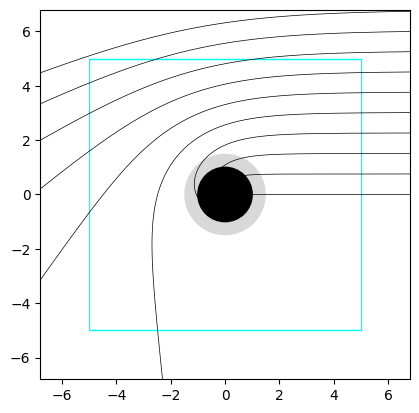

In [17]:
# Initialising the box with a certain size. Make sure the source you have 
# fits inside this box.
box_sphere = Box(box_size=10, box_points=50, viewing_angles=(0,0))

# We then calculate the photon rays for different impact parameters.
box_sphere.calculate_photon_rays(n_b=10, metric=metric, D=1000, b_max=6.8)
# And plotting these calculated photon rays
box_sphere.plot_box_orbits()

When choosing values for box_points and n_b (and later n_alpha) ensure that 
box_points is larger than either of these two values (ideally by an order 
of magnitude).

Additionally, the blue contour indicates the size of the box. The value of b_max
should be taken slightly larger than box_size / 2 to ensure that the entire box 
is covered by photon rays. This can be done by trial and error with a low n_b
and plotting the rays as above.

## Combining to generate an image

In the cell below we add a source to the box. In this case the spherical source,
but you can change it if you like. Run the cell and check whether the resulting 
image looks correct.

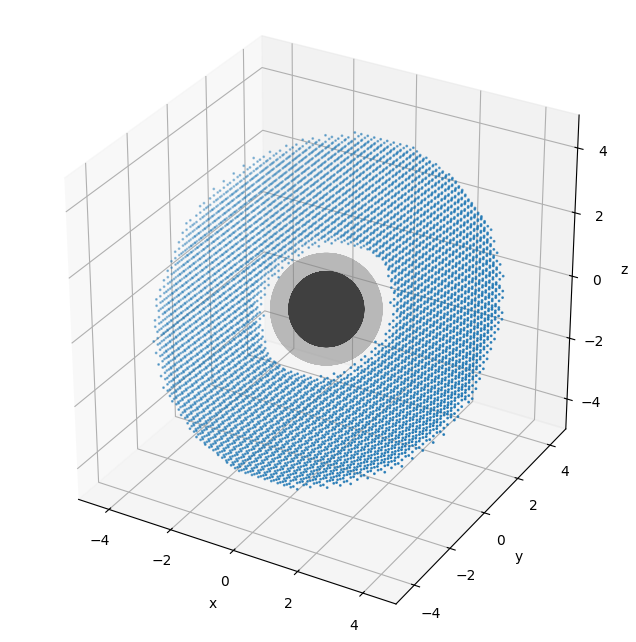

In [ ]:
# We then add our spherical source to the box
box_sphere.add_source(sphere)
# And we can plot it to check the orientation
box_sphere.plot_source()

Finally, generate the image with the cell below.

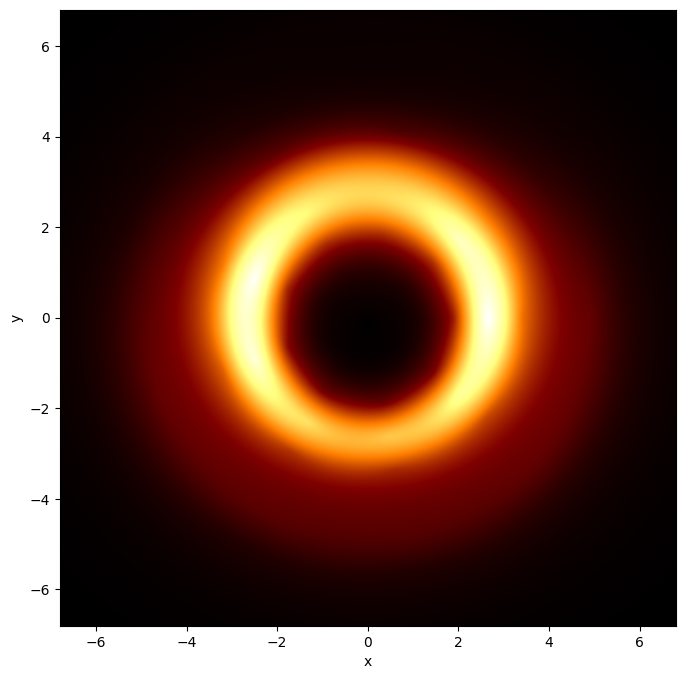

In [13]:
# We can finally calculate the pixel brightness and plot the resulting image
box_sphere.calculate_pixel_brightness(n_alpha=10)
box_sphere.plot_image(smoothing=1, log=False)

The standard log=True option can make fainter features more clearly visible, but
it can also wash out brighter features as shown above. Note that even with this 
very low resolution, the photon ring and black hole shadow are clearly visible.